# LCLS Gun Solenoid (SOL1) FieldMesh

This is an openPMD-beamphysics fieldmap for the center of the LCLS RF Gun

In [1]:
from pmd_beamphysics import FieldMesh

import numpy as np
import os

# Nicer plotting
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
H5FILE = 'lcls_gun_solenoid_fieldmesh.h5'

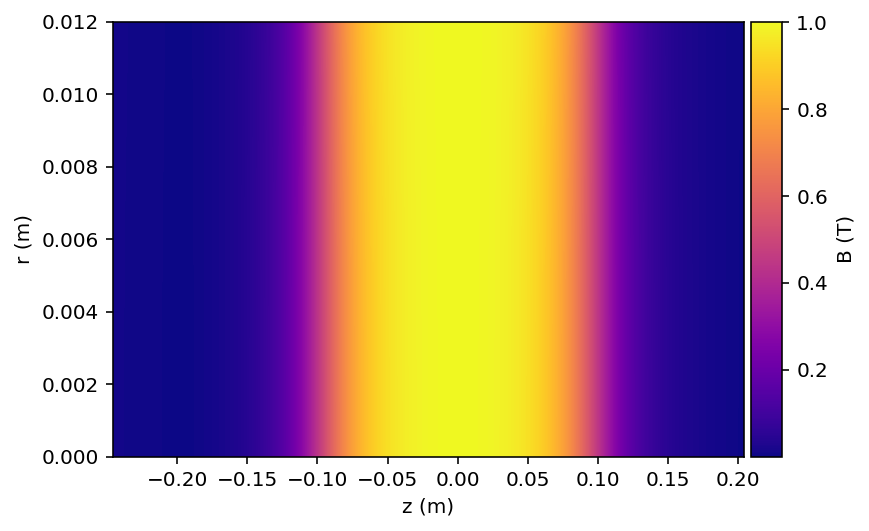

In [3]:
FM = FieldMesh(H5FILE)
FM.plot()

In [4]:
FM.attrs

{'eleAnchorPt': 'beginning',
 'gridGeometry': 'cylindrical',
 'axisLabels': array(['r', 'theta', 'z'], dtype='<U5'),
 'gridLowerBound': array([0, 1, 0]),
 'gridOriginOffset': array([ 0.       ,  0.       , -0.2461135]),
 'gridSpacing': array([0.0005, 0.    , 0.0005]),
 'gridSize': array([ 25,   1, 901]),
 'harmonic': 0,
 'fundamentalFrequency': 0,
 'RFphase': 0,
 'fieldScale': 1.0}

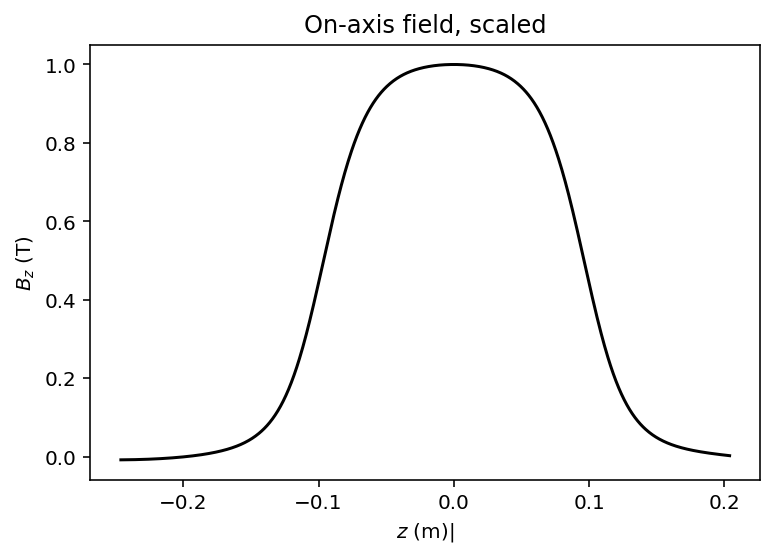

In [5]:
# On-axis field
z0 = FM.z
Bz0 =FM.Bz[0,0,:]/FM.Bz[0,0,:].max()

plt.title('On-axis field, scaled')
plt.xlabel('$z$'+' (m)|')
plt.ylabel('$B_z$'+' (T)')
plt.plot(z0, Bz0, color='black')

# Field integrals

$I_1 = B_0\int B_z(z)$

$I_2 = B_0^2\int B_z^2(z) dz$


In [6]:
# Field integral 1 (T*m)
iB1 = np.trapz(Bz0, z0)
iB1

0.1934524817510171

In [7]:
# Field integral 2 (T^2*m)
iB2 = np.trapz(Bz0**2, z0)
iB2

0.16031587548458337

In [8]:
# Hard-edge equivalent length (m) 
1/(iB2/iB1**2)

0.23343828290559054

# Check that field can be expanded from 1D

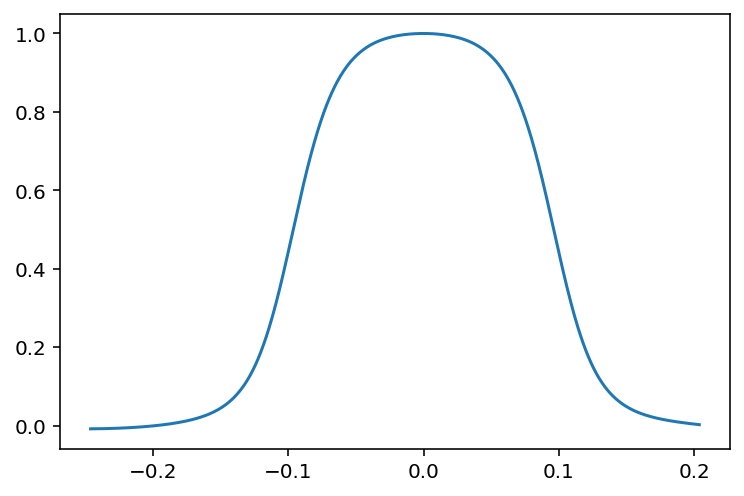

In [9]:
from pmd_beamphysics.fields.expansion import expand_1d_static_fieldmap
Brf, Bzf = expand_1d_static_fieldmap(z0, FM.Bz[0,0,:])

plt.plot(z0, Bzf(0, z0))

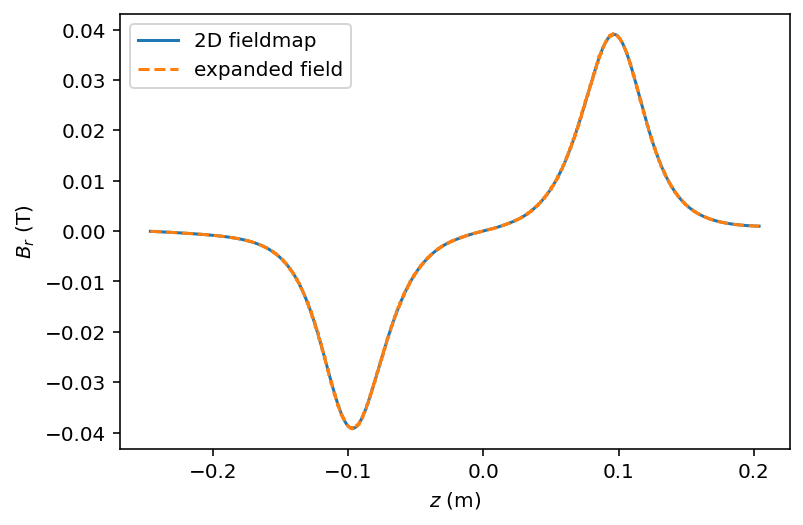

In [10]:
rtry = 0.005
ii = int(rtry//FM.dr)
Br1 = FM.Br[ii, 0, :]

plt.plot(z0, Br1, label='2D fieldmap')
plt.plot(z0, Brf(rtry , z0), linestyle='--', label='expanded field')
plt.xlabel('$z$'+' (m)')
plt.ylabel('$B_r$'+' (T)')
plt.legend()